objective

to build a convolutioal autoencoder(cae) that compresses facial images into a lower-dimensional latent representaton and reconstructs them with minimal loss of information

purpose

a converactional autoencoder is an unsupervised deep learning model used for:

image compression image reconstruction feature extraction dimensionality reduction

the encoder learn a compressed represenatation (latent space ) while the decoder reconsructs the original image from the compressed represenalation

In [92]:
import os # math calcul, access file
import shutil # visualization
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf #

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [93]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kushsheth/face-vae")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-vae' dataset.
Path to dataset files: /kaggle/input/face-vae


In [94]:
import os

# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

Files in the dataset directory: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [95]:
import pandas as pd

# Construct the full path to the CSV file
landmarks_csv_path = os.path.join(path, 'list_landmarks_align_celeba.csv')

# Read the CSV file into a pandas DataFrame
landmarks_df = pd.read_csv(landmarks_csv_path)

# Display the first 5 rows of the DataFrame
display(landmarks_df.head())

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [96]:
import os
import shutil

source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder, image),
      destination_folder
      )
  print("Copied", len(image), "image")

Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 1

In [146]:
#Data Preprocessing

IMAGE_SIZE = (128,128)

BATCH_SIZE = 16

In [147]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [148]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [149]:
#load dataset

validation_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


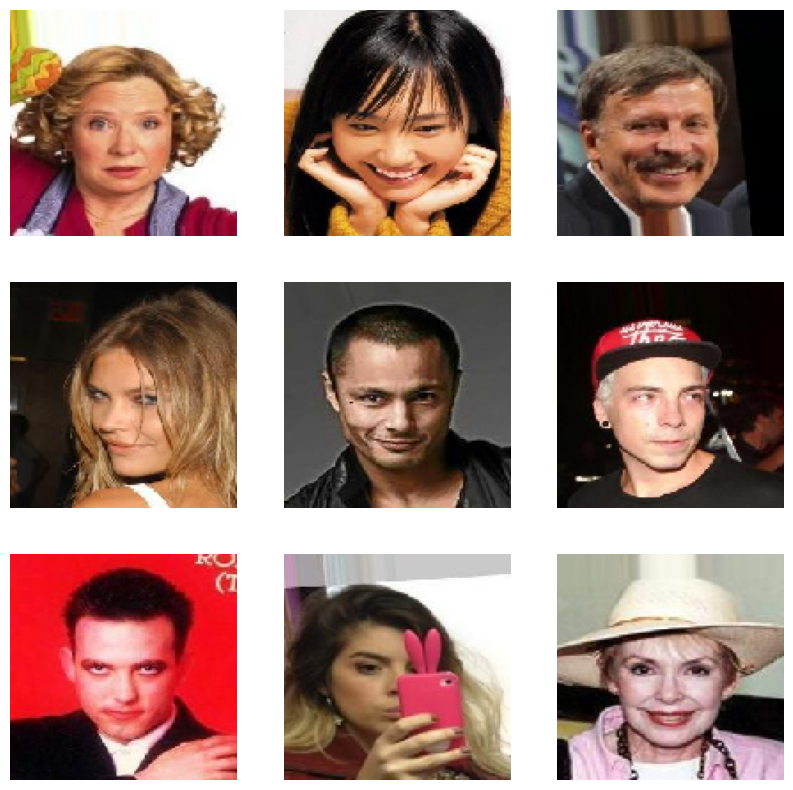

In [150]:
#display sample image
image,_=next(train_generator)
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(image[i])
  plt.axis('off')
plt.show()

encoder

In [159]:
input_img=Input(shape=(128, 128, 3))
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
encoder = MaxPooling2D((2,2),padding='same')(x)

In [160]:
#build decoder

x = Conv2D(64,(3,3),activation='relu',padding='same')(encoder)
x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)
decoder = Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)


In [161]:
#model creation
autoencoder=Model(input_img,decoder)

changed lerning rate

In [176]:
#comiple model
from tensorflow.keras.optimizers import Adam
op=Adam(learning_rate=0.0005)
autoencoder.compile(optimizer=op,loss='binary_crossentropy')

In [177]:
#summary
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [178]:
#train model

history=autoencoder.fit(train_generator,
                        epochs=40,
                        validation_data=validation_generator)

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.4717 - val_loss: 0.4712
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.4708 - val_loss: 0.4710
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.4709 - val_loss: 0.4710
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.4710 - val_loss: 0.4714
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.4708 - val_loss: 0.4712
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.4707 - val_loss: 0.4709
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.4706 - val_loss: 0.4717
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.4714 - val_loss: 0.4711
Epoch 9/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.4706 - val_loss: 0.4709
Epoch 10/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.4705 - val_loss: 0.4711
Epoch 11/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.4704 - val_loss: 0.4710
Epoch 12/40
250/250 ━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_654/2933850553.py:9: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Training','Validation')


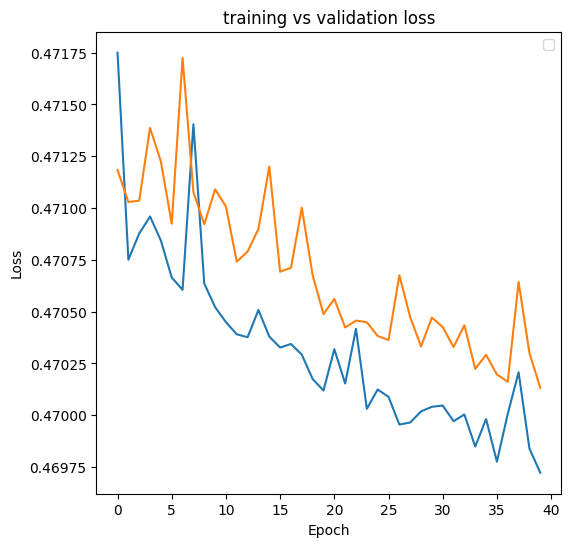

In [179]:
#plot(
plt.figure(figsize=(6,6))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend('Training','Validation')
plt.show()

In [180]:
#evalute model
loss=autoencoder.evaluate(train_generator)
print("loss:",loss)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4697
loss: 0.4696505069732666


In [181]:
#transcript images
image,_=next(train_generator)
recreatedimages=autoencoder.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


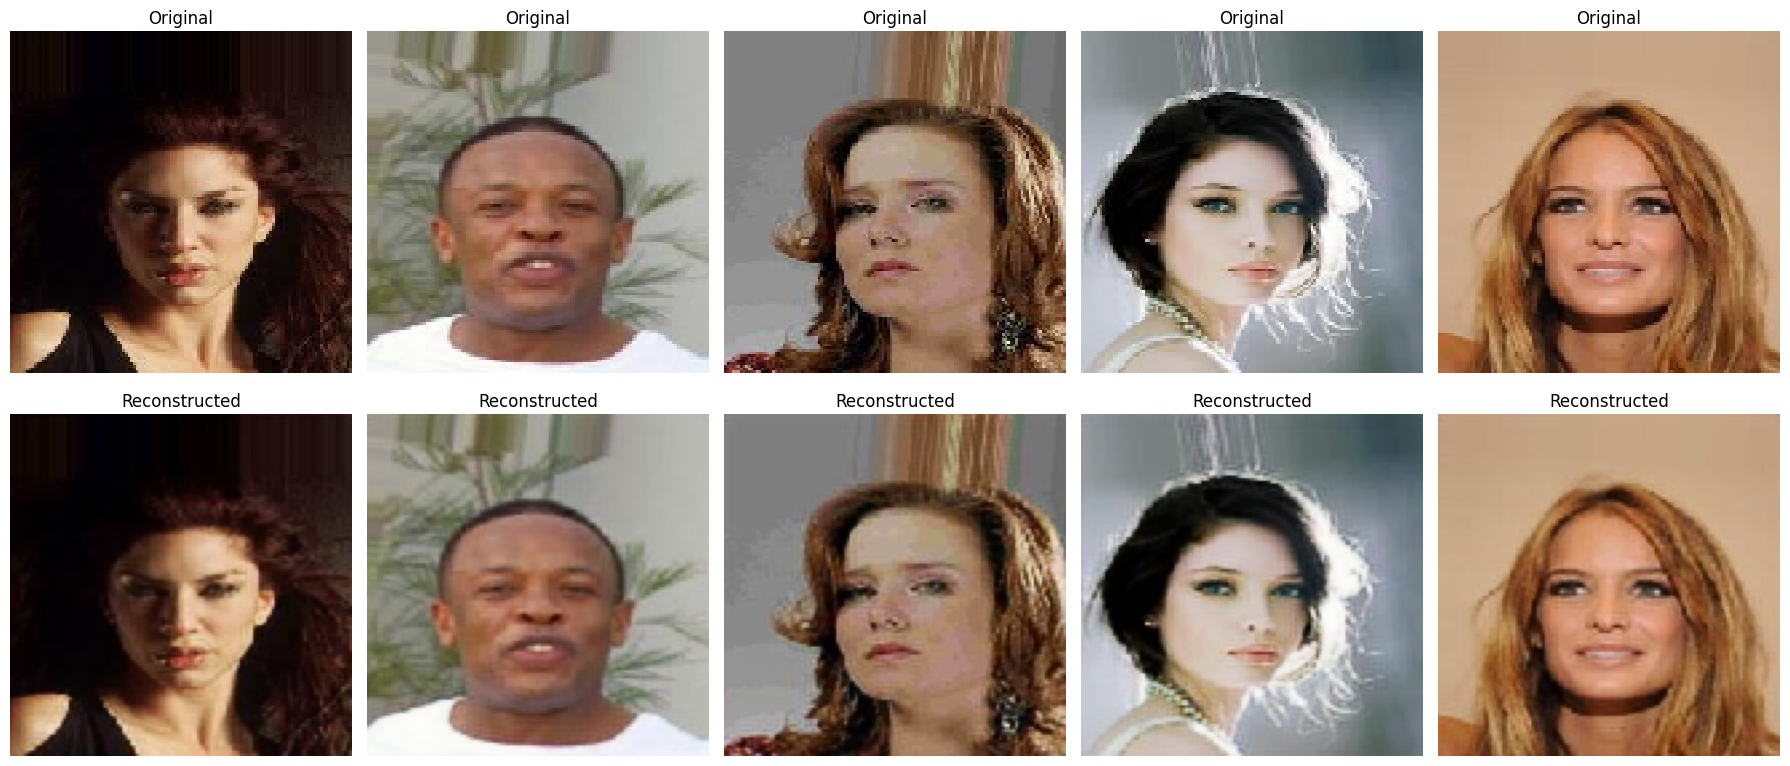

In [182]:
#display results
n= 5
plt.figure(figsize=(18,8))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(image[i], interpolation='nearest')
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(
    np.clip(recreatedimages[i], 0, 1),interpolation='nearest')
    plt.title("Reconstructed")
    plt.axis("off")
    plt.imshow(recreatedimages[i])
plt.tight_layout()
plt.show()
